## Pathway enrichment (ORA)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scanpy as sc
import pandas as pd
import ma_codes as codes
from ma_codes import mysize, gray_red, mymap
import pertpy as pt
import seaborn as sns
from pathlib import Path
import math
import re
import gseapy as gp

try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except ImportError:
    HAS_ADJUSTTEXT = False

sc.settings.verbosity = 3               # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_version_and_date()

Running Scanpy 1.11.4, on 2026-08-27 10:28.


In [2]:
print(gp.__version__)

1.1.10


In [3]:
plt.rcParams['pdf.fonttype'] = 42

In [4]:
# Endothelial cells in endothelial compartments
dge_folder_mild   = "/media/synology/Huijuan/IPF_EC paper/snRNA_IPF_mild_severe/DGE_EC_celltype_MAST/DEG_IPF_Mild_Control/"
dge_folder_severe = "/media/synology/Huijuan/IPF_EC paper/snRNA_IPF_mild_severe/DGE_EC_celltype_MAST/DEG_IPF_Severe_Control/"

## VWA1+/PLVAP+ EC

In [5]:
cell_type_filename = "diffExpResults_PLVAP+_VWA1+_systemic_venous_EC.xlsx"
out_base = "/media/synology/Huijuan/Plots/IPF_subsets/IPF_paper/MAST_EC_pathway/new/PLVAP_VWA1_EC/"

ct_label   = "VWA1+/PLVAP+ bronchial EC"
ct_color   = "#E623B1"
pval_thresh = 0.05
lfc_thresh  = 0.3
TOP_N_LABEL = 20
#GENE_SETS   = ['GO_Biological_Process_2025', 'Reactome_2022', 'MSigDB_Hallmark_2020']

In [6]:
# load DGE table
def load_dge(folder, fname):
    df = pd.read_excel(Path(folder) / fname)
    df = df.rename(columns={"Unnamed: 0": "gene"})
    return df

# Get up/down regulated gene list: p<0.05, |log2FC|>0.5
def get_up_down_genes(df, pval_col="p_val", lfc_col="avg_log2FC",
                       pval_thresh=0.05, lfc_thresh=0.5):
    sub = df.dropna(subset=[pval_col, lfc_col, "gene"])
    up = sub[(sub[pval_col] < pval_thresh) & (sub[lfc_col] > lfc_thresh)]["gene"].tolist()
    down = sub[(sub[pval_col] < pval_thresh) & (sub[lfc_col] < -lfc_thresh)]["gene"].tolist()
    return up, down

# Run Enrichr over-representation analysis
def run_enrichr_up_down(glist_up, glist_down, outdir_up, outdir_down):
    enr_up = gp.enrichr(
        gene_list=glist_up,
        organism='Human',
        gene_sets=['GO_Biological_Process_2025', 'Reactome_2022', 'MSigDB_Hallmark_2020'],
        cutoff=0.05,  # p value
        outdir=outdir_up,
        no_plot=True,
    )
    enr_down = gp.enrichr(
        gene_list=glist_down,
        organism='Human',
        gene_sets=['GO_Biological_Process_2025', 'Reactome_2022', 'MSigDB_Hallmark_2020'],
        cutoff=0.05,
        outdir=outdir_down,
        no_plot=True,
    )
    return enr_up, enr_down

# load enrichment result
def load_results(outdir, gene_set):
    return pd.read_csv(Path(outdir) / f"{gene_set}.Human.enrichr.reports.txt", delimiter="\t")

# ── enrichment bar plot
def make_barplot(go_df, msig_df, go_idx, msig_idx, title, savepath=None,
                  figsize=(2, 3), palette="Reds"):
    go_sel = go_df.iloc[go_idx]
    msig_sel = msig_df.iloc[msig_idx]

    selection = pd.concat([msig_sel, go_sel], axis=0)
    selection["-log10(p_adj)"] = selection["Adjusted P-value"].apply(lambda x: -math.log10(x))
    selection.sort_values(by="-log10(p_adj)", ascending=False, inplace=True)

    fig, ax = plt.subplots()
    fig.set_size_inches(*figsize)
    sns.barplot(
        selection, x="-log10(p_adj)", y="Term", orient="y",
        hue="Gene_set", palette=palette,
        hue_order=["GO_Biological_Process_2025", "MSigDB_Hallmark_2020"]
    )
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.title(title, loc='center')
    if savepath:
        plt.savefig(savepath, bbox_inches="tight")
    return fig, selection

# ── volcano plot ───────────────────────────────────────────────────────────────
def plot_volcano(
    df,
    condition,
    savepath=None,
    save=True,
    show=True,
    pval_col="p_val",
    lfc_col="avg_log2FC",
    figsize=(5, 4.5)
):
    df = df.dropna(subset=[pval_col, lfc_col, "gene"]).copy()

    df["-log10p"] = -np.log10(df[pval_col].clip(lower=1e-300))

    def status(r):
        if r[pval_col] < pval_thresh and r[lfc_col] > lfc_thresh:
            return "up"
        if r[pval_col] < pval_thresh and r[lfc_col] < -lfc_thresh:
            return "down"
        return "ns"

    df["status"] = df.apply(status, axis=1)

    n_up = (df["status"] == "up").sum()
    n_down = (df["status"] == "down").sum()

    color_map = {"up": ct_color, "down": "#4477AA", "ns": "#cccccc"}
    size_map = {"up": 18, "down": 18, "ns": 4}
    alpha_map = {"up": 0.85, "down": 0.85, "ns": 0.3}

    fig, ax = plt.subplots(figsize=figsize)

    for s in ["ns", "down", "up"]:
        sub = df[df["status"] == s]

        ax.scatter(
            sub[lfc_col],
            sub["-log10p"],
            s=size_map[s],
            c=color_map[s],
            alpha=alpha_map[s],
            linewidths=0,
            zorder=1 if s == "ns" else 3,
            rasterized=(s == "ns"),
        )

    ax.axhline(-np.log10(pval_thresh), color="#888888", lw=0.8, ls="--", zorder=2)
    ax.axvline(lfc_thresh, color="#888888", lw=0.8, ls="--", zorder=2)
    ax.axvline(-lfc_thresh, color="#888888", lw=0.8, ls="--", zorder=2)
    ax.axvline(0, color="#444444", lw=0.5, ls="-", zorder=2)

    top = pd.concat([
        df[df["status"] == "up"].nlargest(TOP_N_LABEL, "-log10p"),
        df[df["status"] == "down"].nlargest(TOP_N_LABEL, "-log10p"),
    ])

    texts = [
        ax.text(
            r[lfc_col],
            r["-log10p"],
            r["gene"],
            fontsize=6.5,
            color="#222222",
        )
        for _, r in top.iterrows()
    ]

    if HAS_ADJUSTTEXT:
        adjust_text(
            texts,
            ax=ax,
            arrowprops=dict(arrowstyle="-", color="#aaaaaa", lw=0.5),
        )

    xlim, ylim = ax.get_xlim(), ax.get_ylim()

    ax.text(
        xlim[1] * 0.97,
        ylim[1] * 0.97,
        f"Up: {n_up}",
        ha="right",
        va="top",
        fontsize=8,
        color=ct_color,
        fontweight="bold",
    )

    ax.text(
        xlim[0] * 0.97,
        ylim[1] * 0.97,
        f"Down: {n_down}",
        ha="left",
        va="top",
        fontsize=8,
        color="#4477AA",
        fontweight="bold",
    )

    ax.set_xlabel("log2 Fold Change", fontsize=10)
    ax.set_ylabel("–log10(p value)", fontsize=10)

    ax.set_title(
        f"{ct_label} — {condition}\n"
        f"threshold: p < {pval_thresh}, |log2FC| > {lfc_thresh}",
        fontsize=9,
        fontweight="bold",
    )

    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

    plt.tight_layout()

    if save:
        if savepath is None:
            raise ValueError("savepath must be provided when save=True")

        plt.savefig(savepath, bbox_inches="tight", dpi=300)
        print(f"  Saved: {Path(savepath).name}")

    if show:
        plt.show()

    plt.close(fig)

## Mild vs control

In [7]:
df_mild = load_dge(dge_folder_mild, cell_type_filename)
df_mild.head()

,gene,entrezgene,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,mean_IPF_Mild,mean_Control
0,XIST,7503.0,2.776209e-11,2.777088,0.610,0.126,8.640949e-07,1.003139,0.216808
1,EAPP,55837.0,1.527200e-10,0.364307,0.117,0.063,4.753410e-06,0.110712,0.080852
2,ANAPC16,119504.0,2.936527e-10,-0.673525,0.107,0.116,9.139942e-06,0.101940,0.155653
3,NSD2,7468.0,3.712957e-10,-0.431553,0.112,0.116,1.155658e-05,0.106336,0.137471
4,SQSTM1,8878.0,6.499887e-10,0.475338,0.112,0.053,2.023090e-05,0.106336,0.071096


In [8]:
glist_mild_up, glist_mild_down = get_up_down_genes(df_mild, pval_thresh=pval_thresh, lfc_thresh=lfc_thresh)
print(f"Mild vs Control DEGs— up: {len(glist_mild_up)}, down: {len(glist_mild_down)}")

Mild vs Control DEGs— up: 500, down: 229


In [9]:
print(glist_mild_up)

['XIST', 'EAPP', 'SQSTM1', 'GIGYF1', 'TRIOBP', 'CSRNP1', 'IRF9', 'SLCO2A1', 'EIF4E', 'SNU13', 'EIF4G1', 'PSMD7', 'TOMM6', 'UTP6', 'CDC123', 'TMEM44', 'IREB2', 'EPC2', 'CASKIN2', 'STAMBP', 'ZNF7', 'PTOV1', 'HRH1', 'KDM4A-AS1', 'EIF1B', 'PLEKHM2', 'DNAJC24', 'TMA7', 'PLEKHG1', 'MACF1', 'FAM160A2', 'RPL4', 'SPTBN1', 'HIF1A', 'HDAC1', 'ADAM15', 'LRRC40', 'SHANK3', 'CEMIP2', 'CEBPB', 'NPIPB4', 'RNF10', 'BBS2', 'PEAK1', 'SUN1', 'ITM2A', 'PRKCI', 'POSTN', 'LEF1', 'GSE1', 'SPRY4', 'STAB1', 'NOSTRIN', 'KAT2A', 'MYO5C', 'TBC1D19', 'MAPKAPK5', 'SDHC', 'RNF114', 'KIAA1211L', 'ID1', 'WDR43', 'ARID1A', 'ZSWIM6', 'SLC35B3', 'HYAL1', 'ZNF131', 'SLC48A1', 'CCL14', 'PCBP1-AS1', 'POLG2', 'CDK17', 'VOPP1', 'TULP4', 'PTPRB', 'LIMS2', 'RUFY3', 'EFTUD2', 'SIK3', 'PON2', 'EHBP1L1', 'PTPN18', 'CNOT2', 'UBE2G2', 'LARP1B', 'SLC16A7', 'PKN3', 'TNFAIP1', 'CRBN', 'TCF20', 'CCDC92', 'RAI14', 'ZER1', 'CD93', 'NCBP1', 'ST3GAL1', 'ZNF81', 'PRKAA1', 'NOS3', 'E4F1', 'GCN1', 'API5', 'SHROOM4', 'JAK3', 'RASA4B', 'TPST2', '

  Saved: volcano_PLVAP_VWA1_mild_vs_control.pdf


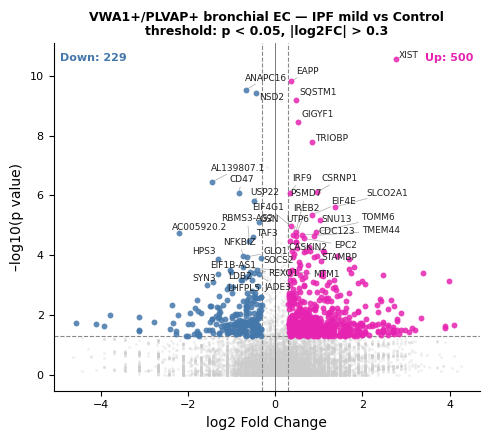

In [10]:
plot_volcano(df_mild, "IPF mild vs Control", save =True, show = True,
             savepath=out_base +"volcano_PLVAP_VWA1_mild_vs_control.pdf")

In [11]:
enr_mild_up, enr_mild_down = run_enrichr_up_down(
    glist_mild_up, glist_mild_down,
    outdir_up=f"{out_base}/mild_up",
    outdir_down=f"{out_base}/mild_down",
)

### Upregulated pathways

In [12]:
GO_mild_up   = load_results(f"{out_base}/mild_up", "GO_Biological_Process_2025")
GO_mild_up.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Regulation of Translation (GO:0006417),17/201,0.000013,0.016001,0,0,3.694887,41.59856,APP;RPL5;SSB;NCBP1;GTDC1;ELP4;YBX1;FOXO3;LARP1...
1,GO_Biological_Process_2025,Post-Transcriptional Regulation of Gene Expres...,9/60,0.000017,0.016001,0,0,6.990176,76.80916,APP;CELF1;GTDC1;MAPKAPK5;RPL15;ELP4;FOXO3;EIF4...
2,GO_Biological_Process_2025,Regulation of Protein Metabolic Process (GO:00...,11/93,0.000021,0.016001,0,0,5.326899,57.50071,APP;TRAF3;SPOP;GTDC1;MAPKAPK5;RPL15;ELP4;FOXO3...
3,GO_Biological_Process_2025,Positive Regulation of DNA-templated Transcrip...,54/1274,0.000102,0.059890,0,0,1.814159,16.66641,RNF10;APP;CSRNP1;BMPR2;TCF20;YBX1;MED16;PKD1;W...
4,GO_Biological_Process_2025,Intracellular Copper Ion Homeostasis (GO:0006878),4/12,0.000163,0.076219,0,0,19.649190,171.39240,APP;COX19;MT2A;ATP7B
5,GO_Biological_Process_2025,Positive Regulation of Transcription by RNA Po...,43/983,0.000276,0.098158,0,0,1.857815,15.22754,KMT2D;RNF10;APP;CSRNP1;CEBPB;BMPR2;HDAC1;EPAS1...
6,GO_Biological_Process_2025,Morphogenesis of an Endothelium (GO:0003159),3/6,0.000294,0.098158,0,0,39.229380,319.05950,CCM2;PRKD2;RHOB
7,GO_Biological_Process_2025,Copper Ion Homeostasis (GO:0055070),4/15,0.000423,0.111211,0,0,14.288120,110.98930,APP;COX19;MT2A;ATP7B
8,GO_Biological_Process_2025,Regulation of DNA Repair (GO:0006282),11/130,0.000428,0.111211,0,0,3.663642,28.41891,BABAM1;RNF168;KAT2A;SMARCC2;SF3B3;ATXN7;EYA3;D...
9,GO_Biological_Process_2025,Transcription by RNA Polymerase II (GO:0006366),14/200,0.000530,0.123986,0,0,2.991239,22.56263,PCID2;NCBP1;ELP4;MED16;MED27;RXRB;MNT;SUB1;NFE...


In [13]:
Msig_mild_up = load_results(f"{out_base}/mild_up", "MSigDB_Hallmark_2020")
Msig_mild_up.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,Myc Targets V1,14/200,0.000530,0.026493,0,0,2.991239,22.562630,CCT3;CCT2;SF3B3;SSB;NCBP1;RPLP0;TUFM;PSMD7;SER...
1,MSigDB_Hallmark_2020,TGF-beta Signaling,6/54,0.002215,0.055375,0,0,4.922065,30.086090,BMPR2;HDAC1;ID1;TGFBR1;SPTBN1;ENG
2,MSigDB_Hallmark_2020,UV Response Up,10/158,0.006494,0.108233,0,0,2.668505,13.440930,RXRB;EIF2S3;POLG2;HYAL2;CDK2;CDC5L;POLR2H;SQST...
3,MSigDB_Hallmark_2020,Angiogenesis,4/36,0.012076,0.150951,0,0,4.906250,21.668580,APP;THBD;POSTN;SLCO2A1
4,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,10/199,0.028450,0.209346,0,0,2.085196,7.422449,ADAM19;PNP;BMPR2;SWAP70;BHLHE40;SPRY4;UMPS;PHL...
5,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,10/200,0.029308,0.209346,0,0,2.074114,7.321370,CEBPB;NAMPT;BHLHE40;SGK1;PHLDA1;SQSTM1;ICAM1;R...
6,MSigDB_Hallmark_2020,Hypoxia,10/200,0.029308,0.209346,0,0,2.074114,7.321370,TPST2;SRPX;MT2A;TES;CAVIN1;DDIT4;HEXA;BHLHE40;...
7,MSigDB_Hallmark_2020,Apoptosis,8/161,0.049644,0.293840,0,0,2.056114,6.174269,APP;CYLD;CDK2;LEF1;BCL10;SQSTM1;CDC25B;RHOB
8,MSigDB_Hallmark_2020,Coagulation,7/138,0.058456,0.293840,0,0,2.099361,5.961086,THBD;VWF;CFI;CAPN2;RAC1;GNG12;DUSP6
9,MSigDB_Hallmark_2020,Unfolded Protein Response,6/113,0.064318,0.293840,0,0,2.201332,6.040277,CEBPB;KHSRP;CNOT2;DDIT4;EIF4E;EIF4G1


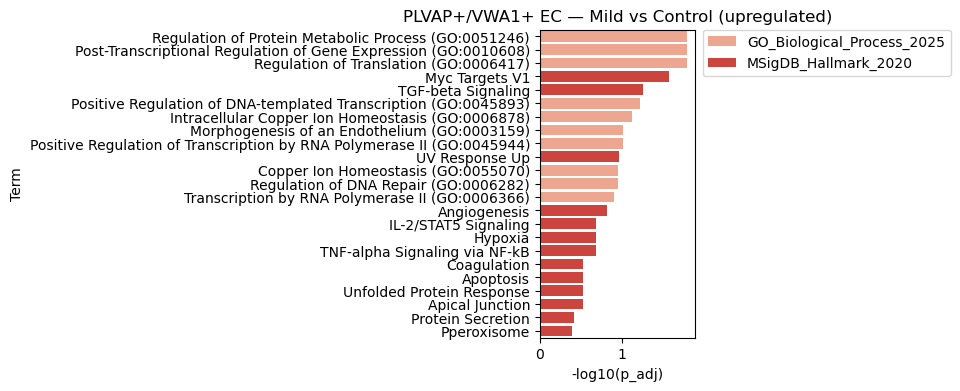

In [14]:
fig_mild_up, sel_mild_up = make_barplot(
    GO_mild_up, Msig_mild_up,
    go_idx=range(0, 10), msig_idx=range(0, 13),
    title="PLVAP+/VWA1+ EC — Mild vs Control (upregulated)",
    savepath=f"{out_base}/PLVAP_VWA1_mild_up.pdf",
    figsize=(2, 4)
)

### Downregulated pathways

In [15]:
GO_mild_down   = load_results(f"{out_base}/mild_down", "GO_Biological_Process_2025")
GO_mild_down.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Regulation of Kinase Activity (GO:0043549),4/27,0.000239,0.199156,0,0,15.264150,127.29560,CD74;EMP2;LDB2;HLA-DRB1
1,GO_Biological_Process_2025,Regulation of Transferase Activity (GO:0051338),3/12,0.000302,0.199156,0,0,29.147490,236.24470,EMP2;LDB2;PUM3
2,GO_Biological_Process_2025,Regulation of Nitric Oxide Biosynthetic Proces...,4/45,0.001727,0.441129,0,0,8.555014,54.42364,HSP90AB1;SMAD3;HBB;CD47
3,GO_Biological_Process_2025,Blood Vessel Endothelial Cell Migration (GO:00...,3/26,0.003171,0.441129,0,0,11.397460,65.57719,NR4A1;EMP2;ROBO1
4,GO_Biological_Process_2025,Peroxisome Proliferator Activated Receptor Sig...,2/8,0.003492,0.441129,0,0,29.023490,164.19000,FAM120B;PPARG
5,GO_Biological_Process_2025,Positive Regulation of Monocyte Differentiatio...,2/9,0.004457,0.441129,0,0,24.876020,134.66340,CD74;HLA-DRB1
6,GO_Biological_Process_2025,Modification-Dependent Macromolecule Catabolic...,2/9,0.004457,0.441129,0,0,24.876020,134.66340,TUT4;UBC
7,GO_Biological_Process_2025,Positive Regulation of Nitric Oxide Biosynthet...,3/30,0.004788,0.441129,0,0,9.706981,51.85068,HSP90AB1;SMAD3;HBB
8,GO_Biological_Process_2025,Positive Regulation of Nitric Oxide Metabolic ...,3/31,0.005257,0.441129,0,0,9.359829,49.12216,HSP90AB1;SMAD3;HBB
9,GO_Biological_Process_2025,Regulation of Extracellular Matrix Assembly (G...,2/10,0.005529,0.441129,0,0,21.765420,113.13190,SMAD3;PPARG


In [16]:
Msig_mild_down = load_results(f"{out_base}/mild_down", "MSigDB_Hallmark_2020")
Msig_mild_down.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,7/199,0.008152,0.097626,0,0,3.215395,15.464390,SOCS2;GABARAPL1;NFKBIZ;LRIG1;MAP3K8;GALM;NDRG1
1,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,7/200,0.008368,0.097626,0,0,3.198572,15.299890,NR4A1;JUN;SMAD3;TSC22D1;PLK2;MAP3K8;IER2
2,MSigDB_Hallmark_2020,Myc Targets V1,7/200,0.008368,0.097626,0,0,3.198572,15.299890,HDDC2;PSMC6;HSP90AB1;PCBP1;GLO1;PRPF31;ABCE1
3,MSigDB_Hallmark_2020,Interferon Alpha Response,4/97,0.025380,0.195865,0,0,3.761625,13.819500,CD74;PSMA3;LAP3;CD47
4,MSigDB_Hallmark_2020,Androgen Response,4/100,0.027981,0.195865,0,0,3.643519,13.030090,TSC22D1;MAK;PTPN21;NDRG1
5,MSigDB_Hallmark_2020,Interferon Gamma Response,5/200,0.080442,0.402208,0,0,2.240842,5.647423,CD74;PSMA3;LAP3;HLA-DQA1;HLA-DRB1
6,MSigDB_Hallmark_2020,p53 Pathway,5/200,0.080442,0.402208,0,0,2.240842,5.647423,JUN;TSC22D1;PLK2;RPS27L;NDRG1
7,MSigDB_Hallmark_2020,Allograft Rejection,4/200,0.197048,0.781903,0,0,1.775510,2.883975,CD74;CD47;ABCE1;HLA-DQA1
8,MSigDB_Hallmark_2020,Cholesterol Homeostasis,2/74,0.207865,0.781903,0,0,2.410548,3.786654,LGALS3;PPARG
9,MSigDB_Hallmark_2020,UV Response Dn,3/144,0.228446,0.781903,0,0,1.848051,2.728565,SMAD3;PTPN21;PPARG


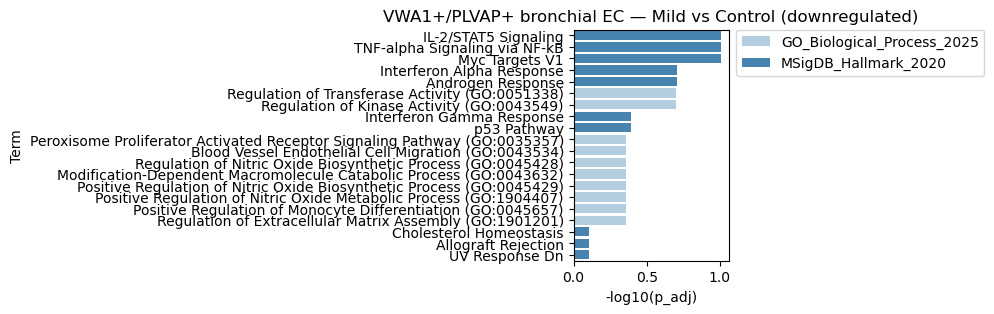

In [18]:
fig_mild_down, sel_mild_down = make_barplot(
    GO_mild_down, Msig_mild_down,
    go_idx=range(0, 10), msig_idx=range(0, 10),
    title="VWA1+/PLVAP+ bronchial EC — Mild vs Control (downregulated)",
    palette="Blues",
)

## Severe vs control

In [19]:
df_severe = load_dge(dge_folder_severe, cell_type_filename)
df_severe.head()

,gene,entrezgene,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,mean_IPF_Severe,mean_Control
0,RBM28,55131.0,8.495568e-12,-0.535939,0.056,0.053,2.644245e-07,0.054067,0.071096
1,NUDT4,11163.0,2.112238e-11,0.432352,0.058,0.074,6.574340e-07,0.105361,0.071096
2,XIST,7503.0,5.363465e-10,0.704265,0.157,0.126,1.669378e-05,0.342945,0.216808
3,IRF9,10379.0,1.433997e-09,0.133144,0.076,0.042,4.463315e-05,0.075370,0.061244
4,SPNS2,124976.0,1.580282e-09,0.794210,0.409,0.200,4.918628e-05,0.492476,0.305936


In [20]:
glist_severe_up, glist_severe_down = get_up_down_genes(df_severe, pval_thresh=pval_thresh, lfc_thresh=lfc_thresh)
print(f"Severe vs Control DEGs— up: {len(glist_severe_up)}, down: {len(glist_severe_down)}")

Severe vs Control DEGs— up: 564, down: 428


  Saved: volcano_PLVAP_VWA1_severe_vs_control.pdf


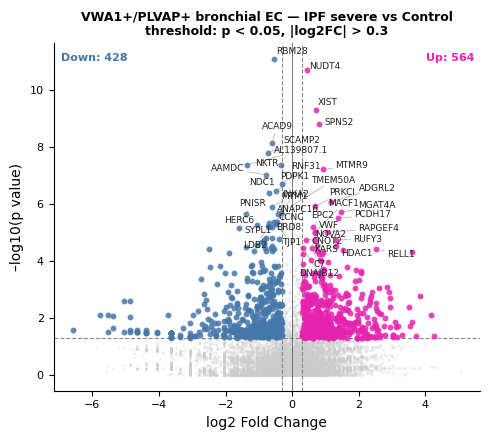

In [21]:
plot_volcano(df_severe, "IPF severe vs Control", save =True, show = True,
             savepath=out_base +"volcano_PLVAP_VWA1_severe_vs_control.pdf")

In [22]:
enr_severe_up, enr_severe_down = run_enrichr_up_down(
    glist_severe_up, glist_severe_down,
    outdir_up=f"{out_base}/severe_up",
    outdir_down=f"{out_base}/severe_down",
)

### Upregulated pathways

In [23]:
GO_severe_up   = load_results(f"{out_base}/severe_up", "GO_Biological_Process_2025")
GO_severe_up.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Blood Vessel Endothelial Cell Migration (GO:00...,8/26,3.797037e-07,0.000974,0,0,15.521980,229.47500,NRP1;EHD4;MICALL1;ID1;PIK3R3;MYH9;FGF13;ROBO1
1,GO_Biological_Process_2025,Positive Regulation of Transcription by RNA Po...,55/983,1.043054e-06,0.001021,0,0,2.155045,29.68221,APP;CSRNP1;GABPB2;CCNT2;BMPR2;MAML1;YBX1;GABPB...
2,GO_Biological_Process_2025,Negative Regulation of Cell Migration (GO:0030...,19/184,1.194413e-06,0.001021,0,0,4.071715,55.52947,GSK3B;HDAC1;DAB2IP;NR2F2;PTPRK;GTPBP4;ROBO1;RA...
3,GO_Biological_Process_2025,Positive Regulation of Signal Transduction (GO...,22/256,3.886427e-06,0.002491,0,0,3.330842,41.49569,ACVR1;APP;MACF1;PRKCI;POGLUT1;VWF;CSNK2A2;DAB2...
4,GO_Biological_Process_2025,Regulation of Vascular Endothelial Growth Fact...,7/26,5.637129e-06,0.002891,0,0,12.843140,155.22400,NRP1;PDCD6;NEDD4;DAB2IP;PRKD2;HIF1A;ROBO1
5,GO_Biological_Process_2025,Positive Regulation of DNA-templated Transcrip...,63/1274,9.846895e-06,0.004208,0,0,1.892458,21.81692,APP;CSRNP1;GABPB2;CCNT2;BMPR2;MAML1;PHF20;YBX1...
6,GO_Biological_Process_2025,Regulation of Transcription by RNA Polymerase ...,97/2250,1.262501e-05,0.004624,0,0,1.667362,18.80756,APP;GABPB2;CCNT2;MAML1;GABPB1;ETS2;DACH1;MYC;N...
7,GO_Biological_Process_2025,Regulation of Cell Migration (GO:0030334),31/479,1.715532e-05,0.005498,0,0,2.465107,27.05011,CCL14;MACF1;GSK3B;HDAC1;LEF1;PIK3R3;PTPRK;CCAR...
8,GO_Biological_Process_2025,Cell Migration Involved in Sprouting Angiogene...,6/22,2.485361e-05,0.007081,0,0,13.051080,138.37410,NRP1;EHD4;MICALL1;PIK3R3;FGF13;ROBO1
9,GO_Biological_Process_2025,Regulation of Endothelial Cell Migration (GO:0...,11/88,3.652750e-05,0.009366,0,0,5.001033,51.09778,NRP1;PDCD6;RHOJ;DAB2IP;ITGB1BP1;PRKD2;PRCP;NR2...


In [24]:
Msig_severe_up = load_results(f"{out_base}/severe_up", "MSigDB_Hallmark_2020")
Msig_severe_up.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,TGF-beta Signaling,10/54,0.000002,0.000115,0,0,7.955366,103.278900,ACVR1;SKI;FKBP1A;BMPR2;SMURF2;SLC20A1;HDAC1;ID...
1,MSigDB_Hallmark_2020,Angiogenesis,5/36,0.003206,0.080145,0,0,5.598996,32.153880,APP;NRP1;POSTN;SLCO2A1;ITGAV
2,MSigDB_Hallmark_2020,Mitotic Spindle,12/199,0.011083,0.180506,0,0,2.237735,10.074970,CYTH2;DOCK4;OPHN1;ARHGDIA;FLNA;CEP250;ARAP3;MY...
3,MSigDB_Hallmark_2020,Apoptosis,10/161,0.016128,0.180506,0,0,2.305329,9.514540,IFITM3;APP;CYLD;PPP3R1;SATB1;SLC20A1;LEF1;EMP1...
4,MSigDB_Hallmark_2020,Hedgehog Signaling,4/36,0.018051,0.180506,0,0,4.331250,17.388130,NRP1;OPHN1;MYH9;ETS2
5,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,10/199,0.056175,0.412274,0,0,1.838195,5.292688,IFITM3;NRP1;PRKCH;BMPR2;MYC;SWAP70;EMP1;ITGAV;...
6,MSigDB_Hallmark_2020,KRAS Signaling Up,10/200,0.057718,0.412274,0,0,1.828425,5.214996,NRP1;GYPC;SATB1;EPB41L3;PECAM1;EMP1;STRN;CROT;...
7,MSigDB_Hallmark_2020,Pancreas Beta Cells,3/40,0.102498,0.568620,0,0,2.803729,6.386657,LMO2;FOXO1;SRP9
8,MSigDB_Hallmark_2020,Apical Junction,9/200,0.113766,0.568620,0,0,1.633932,3.551535,CAP1;VWF;ITGA10;CDH11;EXOC4;PECAM1;PIK3R3;MYH9...
9,MSigDB_Hallmark_2020,Wnt-beta Catenin Signaling,3/42,0.114418,0.568620,0,0,2.659674,5.765909,MAML1;MYC;LEF1


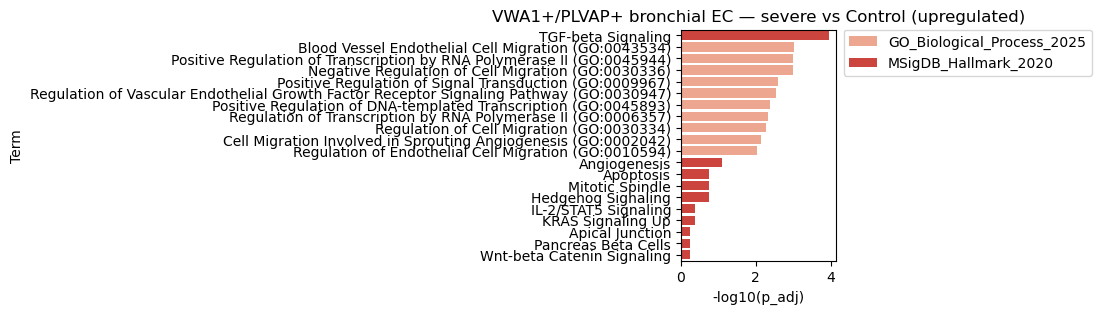

In [25]:
fig_severe_up, sel_severe_up = make_barplot(
    GO_severe_up, Msig_severe_up,
    go_idx=range(0, 10), msig_idx=range(0, 10),
    title="VWA1+/PLVAP+ bronchial EC — severe vs Control (upregulated)",
)

### Downregulated pathways

In [26]:
GO_severe_down   = load_results(f"{out_base}/severe_down", "GO_Biological_Process_2025")
GO_severe_down.head(15)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Regulation of Sprouting Angiogenesis (GO:1903670),5/38,0.001230,0.701252,0,0,6.998711,46.89741,PPP1R16B;TJP1;CEACAM1;PDPK1;GLUL
1,GO_Biological_Process_2025,Negative Regulation of Actin Filament Depolyme...,2/5,0.004377,0.701252,0,0,30.624410,166.32980,LIMA1;PIK3CA
2,GO_Biological_Process_2025,Early Endosome to Golgi Transport (GO:0034498),3/16,0.004429,0.701252,0,0,10.620270,57.55762,LMAN1;SNX2;STX5
3,GO_Biological_Process_2025,Protein Localization to Vacuole (GO:0072665),3/16,0.004429,0.701252,0,0,10.620270,57.55762,SZT2;LMBRD1;GBP1
4,GO_Biological_Process_2025,Regulation of Organelle Organization (GO:0033043),7/97,0.004821,0.701252,0,0,3.599208,19.20087,TJP1;LMAN1;AKAP9;EP300;STX5;SQSTM1;MTM1
5,GO_Biological_Process_2025,Positive Regulation by Host of Viral Transcrip...,3/17,0.005293,0.701252,0,0,9.861176,51.68526,JUN;EP300;NUCKS1
6,GO_Biological_Process_2025,Regulation of Neurotransmitter Transport (GO:0...,3/18,0.006252,0.701252,0,0,9.203294,46.70480,DYSF;SNCAIP;MCTP2
7,GO_Biological_Process_2025,Detection of Temperature Stimulus Involved in ...,2/6,0.006473,0.701252,0,0,22.967140,115.75530,MMP24;EPHB1
8,GO_Biological_Process_2025,Detection of Temperature Stimulus Involved in ...,2/6,0.006473,0.701252,0,0,22.967140,115.75530,MMP24;EPHB1
9,GO_Biological_Process_2025,Regulation of Type 2 Mitophagy (GO:1905089),2/7,0.008935,0.701252,0,0,18.372770,86.67847,HOOK2;VPS13C


In [27]:
Msig_severe_down = load_results(f"{out_base}/severe_down", "MSigDB_Hallmark_2020")
Msig_severe_down.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,Androgen Response,6/100,0.020512,0.467400,0,0,2.946153,11.450920,LMAN1;TSC22D1;TMEM50A;SELENOP;PTPN21;SLC38A2
1,MSigDB_Hallmark_2020,Apoptosis,8/161,0.022800,0.467400,0,0,2.417554,9.140759,JUN;CDKN1B;GSN;FEZ1;CASP1;TIMP3;PLAT;SQSTM1
2,MSigDB_Hallmark_2020,Interferon Alpha Response,5/97,0.057278,0.782805,0,0,2.502827,7.157663,RNF31;PSMA3;LPAR6;CASP1;HERC6
3,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,7/200,0.138591,0.987070,0,0,1.669514,3.299345,JUN;TSC22D1;TIPARP;ID2;MAP3K8;SQSTM1;BIRC2
4,MSigDB_Hallmark_2020,Interferon Gamma Response,6/200,0.258088,0.987070,0,0,1.420189,1.923580,SELP;RNF31;PSMA3;CASP1;HLA-DQA1;HERC6
5,MSigDB_Hallmark_2020,Myc Targets V1,6/200,0.258088,0.987070,0,0,1.420189,1.923580,DDX18;PSMC6;HSP90AB1;PCBP1;PRPF31;ABCE1
6,MSigDB_Hallmark_2020,IL-6/JAK/STAT3 Signaling,3/87,0.285466,0.987070,0,0,1.637647,2.053005,JUN;LEPR;MAP3K8
7,MSigDB_Hallmark_2020,TGF-beta Signaling,2/54,0.321939,0.987070,0,0,1.762369,1.997460,TJP1;ID2
8,MSigDB_Hallmark_2020,Protein Secretion,3/96,0.338215,0.987070,0,0,1.478482,1.602785,LMAN1;SNX2;CLCN3
9,MSigDB_Hallmark_2020,Coagulation,4/138,0.342106,0.987070,0,0,1.368488,1.467888,C3;GSN;TIMP3;PLAT


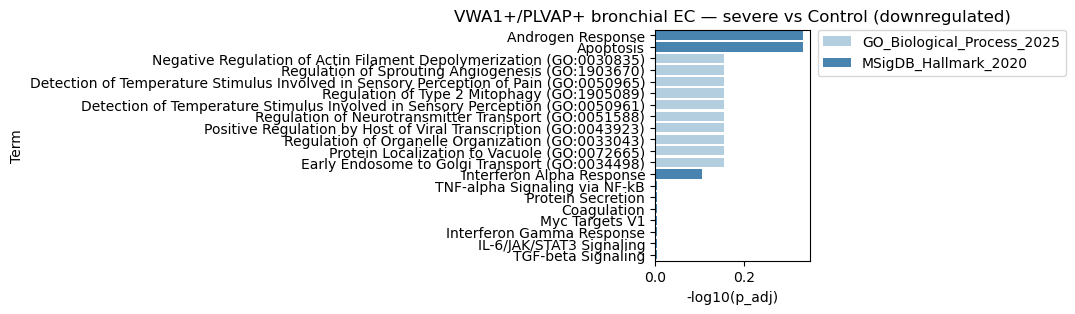

In [28]:
fig_severe_down, sel_severe_down = make_barplot(
    GO_severe_down, Msig_severe_down,
    go_idx=range(0, 10), msig_idx=range(0, 10),
    title="VWA1+/PLVAP+ bronchial EC — severe vs Control (downregulated)",
    palette="Blues",
)

In [29]:
print(f"Mild vs Control — up: {len(glist_mild_up)}, down: {len(glist_mild_down)}")
print(f"Severe vs Control — up: {len(glist_severe_up)}, down: {len(glist_severe_down)}")

Mild vs Control — up: 500, down: 229
Severe vs Control — up: 564, down: 428


In [30]:
print("Upregulated genes (Mild vs Control):")
print(glist_mild_up)

Upregulated genes (Mild vs Control):
['XIST', 'EAPP', 'SQSTM1', 'GIGYF1', 'TRIOBP', 'CSRNP1', 'IRF9', 'SLCO2A1', 'EIF4E', 'SNU13', 'EIF4G1', 'PSMD7', 'TOMM6', 'UTP6', 'CDC123', 'TMEM44', 'IREB2', 'EPC2', 'CASKIN2', 'STAMBP', 'ZNF7', 'PTOV1', 'HRH1', 'KDM4A-AS1', 'EIF1B', 'PLEKHM2', 'DNAJC24', 'TMA7', 'PLEKHG1', 'MACF1', 'FAM160A2', 'RPL4', 'SPTBN1', 'HIF1A', 'HDAC1', 'ADAM15', 'LRRC40', 'SHANK3', 'CEMIP2', 'CEBPB', 'NPIPB4', 'RNF10', 'BBS2', 'PEAK1', 'SUN1', 'ITM2A', 'PRKCI', 'POSTN', 'LEF1', 'GSE1', 'SPRY4', 'STAB1', 'NOSTRIN', 'KAT2A', 'MYO5C', 'TBC1D19', 'MAPKAPK5', 'SDHC', 'RNF114', 'KIAA1211L', 'ID1', 'WDR43', 'ARID1A', 'ZSWIM6', 'SLC35B3', 'HYAL1', 'ZNF131', 'SLC48A1', 'CCL14', 'PCBP1-AS1', 'POLG2', 'CDK17', 'VOPP1', 'TULP4', 'PTPRB', 'LIMS2', 'RUFY3', 'EFTUD2', 'SIK3', 'PON2', 'EHBP1L1', 'PTPN18', 'CNOT2', 'UBE2G2', 'LARP1B', 'SLC16A7', 'PKN3', 'TNFAIP1', 'CRBN', 'TCF20', 'CCDC92', 'RAI14', 'ZER1', 'CD93', 'NCBP1', 'ST3GAL1', 'ZNF81', 'PRKAA1', 'NOS3', 'E4F1', 'GCN1', 'API5', 'S

In [31]:
print("Upregulated genes (Severe vs Control):")
print(glist_severe_up)

Upregulated genes (Severe vs Control):
['NUDT4', 'XIST', 'SPNS2', 'MTMR9', 'ADGRL2', 'PRKCI', 'MGAT4A', 'PCDH17', 'EPC2', 'MACF1', 'RAPGEF4', 'VWF', 'CNOT2', 'RUFY3', 'NOVA2', 'HDAC1', 'KARS', 'DNAJB12', 'C7', 'RELL1', 'SLCO2A1', 'LCLAT1', 'SUN1', 'LEF1', 'ANO2', 'TMEM44', 'SFT2D1', 'CMIP', 'DACH1', 'ZHX3', 'HSPG2', 'VOPP1', 'SRPX', 'C1orf159', 'PALD1', 'AUTS2', 'PIK3R3', 'EXT2', 'RAB3C', 'DOCK4', 'MYO5C', 'DLC1', 'MTF2', 'SWAP70', 'ITGAV', 'UTP6', 'MYRIP', 'HDAC4', 'TPST2', 'MYH9', 'NDST1', 'LINC02147', 'SBNO2', 'SASH1', 'ZEB1', 'KLHL2', 'HDAC8', 'GFOD2', 'PTPRB', 'NAA35', 'RHOJ', 'PXDN', 'PHLDA1', 'NRP1', 'SNRK', 'ZBTB16', 'FAM172A', 'LMO2', 'CLCN6', 'NAMPT', 'HIF1A', 'ROBO1', 'EYA3', 'LMBR1', 'PON2', 'MRRF', 'PCAT1', 'PREX2', 'CD59', 'PEAR1', 'POSTN', 'PTPRK', 'FAM171B', 'PIK3C3', 'SYNE3', 'PGS1', 'PRKG1', 'DOCK6', 'CDK17', 'CDC123', 'SH3YL1', 'NUAK1', 'SDE2', 'SPIRE1', 'MEF2A', 'AL159156.1', 'CFI', 'MARCH3', 'SNX8', 'ID1', 'BMPR2', 'ANO5', 'GABPB1', 'LRP6', 'PLEKHG1', 'CPSF6', 'SHI

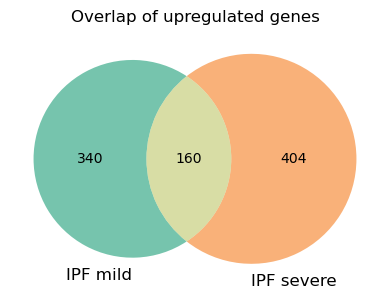

Overlap genes: 160
['AC048341.1', 'AC103591.3', 'ADAMTS3', 'AFTPH', 'AHCYL2', 'AL136985.3', 'AL359220.1', 'AMBRA1', 'API5', 'APP', 'ATP11A', 'BAIAP2L1', 'BMPR2', 'CALCRL', 'CAP1', 'CASKIN2', 'CCAR1', 'CCDC92', 'CCL14', 'CCM2', 'CCT3', 'CD59', 'CD93', 'CDC123', 'CDK17', 'CEMIP2', 'CFI', 'CMIP', 'CMTM4', 'CNOT2', 'CSRNP1', 'CYLD', 'DHX57', 'DNAJC18', 'DOCK6', 'DPF3', 'EED', 'EGFL7', 'EIF4E', 'EIF4G3', 'ENG', 'ENTPD1', 'EPAS1', 'EPC2', 'EYA3', 'FAM160A2', 'FAM210A', 'FAR1', 'FUBP3', 'GDAP2', 'GFOD2', 'GSE1', 'HDAC1', 'HEXA', 'HIF1A', 'HYAL1', 'HYAL2', 'ID1', 'IGFBP4', 'IMMT', 'IRF2BP2', 'ITGB1BP1', 'JAK3', 'KCMF1', 'KCNC4', 'KIAA1211L', 'KLHL2', 'LEF1', 'LMBR1', 'LRRC4C', 'LUZP1', 'MACF1', 'MED14', 'MGAT4A', 'MRRF', 'MSANTD2', 'MYH9', 'MYO5C', 'NAMPT', 'NCAPD2', 'NEURL1B', 'NOX4', 'NR2F2-AS1', 'PALD1', 'PARVB', 'PCID2', 'PGS1', 'PHLDA1', 'PITPNC1', 'PKN3', 'PLEKHG1', 'PLXNA2', 'PON2', 'POSTN', 'PPP4R3B', 'PRKCI', 'PRKD2', 'PTCHD4', 'PTPN18', 'PTPRB', 'PTPRK', 'RAB5A', 'RAMP3', 'RAPGEF4', 

In [32]:
from matplotlib_venn import venn2
mild_up = set(glist_mild_up)
severe_up = set(glist_severe_up)

overlap_genes = mild_up & severe_up

plt.figure(figsize=(4, 4))

venn2(
    [mild_up, severe_up],
    set_labels=("IPF mild", "IPF severe"),
    set_colors=("#1B9E77", "#F57E20"),
    alpha=0.6,
)

plt.title("Overlap of upregulated genes")
plt.tight_layout()
# Save the figure
plt.savefig(out_base + "venn_upregulated_genes.pdf", bbox_inches="tight")
plt.show()

print(f"Overlap genes: {len(overlap_genes)}")
print(sorted(overlap_genes))

In [33]:
# Up in only mild
mild_specific_up = mild_up - severe_up

print(f"Mild-specific upregulated genes: {len(mild_specific_up)}")
print(sorted(mild_specific_up))

Mild-specific upregulated genes: 340
['ABHD17A', 'AC008467.1', 'AC010976.2', 'AC026471.4', 'AC068733.3', 'ACOT7', 'ADAM15', 'ADAM19', 'ADCY4', 'AFF4', 'AGFG2', 'AIF1L', 'AKAP8', 'AL008633.1', 'AL033504.1', 'AL049869.3', 'AL158212.3', 'AL589935.1', 'AL603840.1', 'ALDH16A1', 'ANAPC10', 'AP3B1', 'APOL3', 'ARFRP1', 'ARHGAP23', 'ARID1A', 'ATAD3B', 'ATP5MG', 'ATP6V1A', 'ATP7B', 'ATXN7', 'B4GALT5', 'BABAM1', 'BBS2', 'BBS9', 'BCL10', 'BHLHE40', 'BLMH', 'BSDC1', 'CADM3-AS1', 'CALM1', 'CAPN2', 'CAVIN1', 'CCL16', 'CCT2', 'CD46', 'CDC25B', 'CDC5L', 'CDK2', 'CEBPB', 'CELF1', 'CLTA', 'CNST', 'COL23A1', 'COPS8', 'COX19', 'CPPED1', 'CRBN', 'CSNK1D', 'CSTB', 'CTC1', 'CYB5R4', 'DCAF13', 'DCAF7', 'DDIT4', 'DDOST', 'DDX17', 'DHX30', 'DLGAP2', 'DNAJC24', 'DNASE1', 'DNMT1', 'DRAM2', 'DUSP6', 'E4F1', 'EAPP', 'ECH1', 'EEF1AKMT1', 'EFCAB14', 'EFTUD2', 'EHBP1L1', 'EIF1B', 'EIF2B3', 'EIF2S3', 'EIF3L', 'EIF4G1', 'ELK3', 'ELMOD3', 'ELMSAN1', 'ELOVL5', 'ELP4', 'EML3', 'EPN2', 'ERLEC1', 'ETAA1', 'EXOG', 'FAM122B', '

In [34]:
# Up in only severe
severe_specific_up = severe_up - mild_up

print(f"Severe-specific upregulated genes: {len(severe_specific_up)}")
print(sorted(severe_specific_up))

Severe-specific upregulated genes: 404
['ABI3', 'AC007364.1', 'AC007743.1', 'AC009961.1', 'AC022182.1', 'AC023389.1', 'AC083855.2', 'AC090517.5', 'AC244131.2', 'ACKR1', 'ACSL4', 'ACSS2', 'ACTR1A', 'ACVR1', 'ADAMTS9', 'ADGRL2', 'ADGRL3', 'ADNP', 'AEBP2', 'AFAP1', 'AHRR', 'AKAP11', 'AL021707.1', 'AL049569.1', 'AL050309.1', 'AL096803.2', 'AL138799.4', 'AL159156.1', 'AL356356.1', 'AL583785.1', 'ANAPC4', 'ANAPC7', 'ANO2', 'ANO5', 'AP2A1', 'AP2S1', 'AP5M1', 'APOL2', 'AQP1', 'ARAP3', 'ARHGAP5', 'ARHGDIA', 'ARHGEF10', 'ARMCX4', 'ASCC2', 'ATAD2', 'ATAD2B', 'ATF6', 'ATF7IP2', 'ATP6V1C1', 'AUTS2', 'AZI2', 'B3GLCT', 'BID', 'BLOC1S5', 'BRAF', 'BUD23', 'C12orf4', 'C19orf18', 'C1orf159', 'C7', 'CACUL1', 'CASC15', 'CCDC14', 'CCNT2', 'CD200', 'CDC16', 'CDH11', 'CDYL', 'CDYL2', 'CEP250', 'CFDP1', 'CHST15', 'CLCN6', 'CLNS1A', 'CMPK1', 'CNDP2', 'CNKSR3', 'CNOT11', 'COL12A1', 'COL21A1', 'COL25A1', 'COP1', 'CPNE5', 'CPSF6', 'CROT', 'CRYL1', 'CSGALNACT1', 'CSNK2A2', 'CYTH2', 'DAB2IP', 'DACH1', 'DCP1A', 'DDX5